# 보너스 실습: AutoML 시계열 예측 — 매장 매출 예측 📈

**시나리오**: 당신은 리테일 기업의 데이터 분석가입니다. 경영진이 다음 달 매출 예측을 요청했습니다.
과거 매출 데이터를 기반으로 AutoML Forecasting을 활용하여 매출을 예측하고,
재고 계획과 인력 배치에 활용할 수 있는 인사이트를 도출하세요.

**배울 것**:
- `databricks.automl.forecast()` API 사용법
- 시계열 데이터 전처리 (날짜 형식, 결측 처리)
- 단일/다중 시계열(multi-series) 예측
- Prophet & ARIMA 모델 결과 해석
- 예측 결과를 비즈니스 의사결정에 연결하기

**소요 시간**: ~60분

## Part 1: 데이터 준비 — 리테일 매출 데이터 생성

실제 업무에서는 POS 시스템이나 데이터 웨어하우스에서 데이터를 가져오겠지만,
여기서는 현실적인 패턴을 가진 시뮬레이션 데이터를 생성합니다.

In [0]:
import pandas as pd
import numpy as np
from pyspark.sql import functions as F
from pyspark.sql.types import *

np.random.seed(42)

# 2년간 일별 매출 데이터 생성 (3개 매장)
dates = pd.date_range("2023-01-01", "2025-02-28", freq="D")
stores = ["Seoul_Gangnam", "Seoul_Hongdae", "Busan_Haeundae"]

records = []
for store in stores:
    # 매장별 기본 매출 수준
    base_sales = {"Seoul_Gangnam": 5000, "Seoul_Hongdae": 3500, "Busan_Haeundae": 2800}
    base = base_sales[store]

    for date in dates:
        # 1) 연간 성장 트렌드 (연 10% 성장)
        years_from_start = (date - dates[0]).days / 365
        trend = base * (1 + 0.10 * years_from_start)

        # 2) 계절성 — 여름(7~8월) 피크, 겨울(1~2월) 저조
        month = date.month
        seasonality = {1: 0.75, 2: 0.78, 3: 0.90, 4: 0.95, 5: 1.05,
                       6: 1.10, 7: 1.25, 8: 1.20, 9: 1.05, 10: 0.95,
                       11: 1.00, 12: 1.15}  # 12월 연말 세일
        seasonal = trend * seasonality[month]

        # 3) 요일 효과 — 주말 매출 증가
        dow = date.dayofweek
        weekend_effect = 1.35 if dow >= 5 else 1.0  # 토/일 35% 증가
        friday_effect = 1.15 if dow == 4 else 1.0   # 금요일 15% 증가

        # 4) 특별 이벤트 (명절, 블랙프라이데이 등)
        special = 1.0
        if month == 1 and 20 <= date.day <= 25:  # 설날 연휴
            special = 1.5
        elif month == 9 and 15 <= date.day <= 20:  # 추석 연휴
            special = 1.4
        elif month == 11 and 24 <= date.day <= 27:  # 블랙프라이데이
            special = 1.8

        # 5) 랜덤 노이즈
        noise = np.random.normal(0, base * 0.08)

        daily_sales = max(0, seasonal * weekend_effect * friday_effect * special + noise)

        records.append({
            "date": date,
            "store_id": store,
            "daily_sales": round(daily_sales, 2),
            "day_of_week": date.strftime("%A"),
            "is_weekend": 1 if dow >= 5 else 0,
            "month": month,
        })

sales_pdf = pd.DataFrame(records)
sales_df = spark.createDataFrame(sales_pdf)

# Unity Catalog 테이블로 저장
CATALOG = "3dt005_databricks"   # ⚠️ 수강생 환경에 맞게 수정
SCHEMA = "default"

sales_df.write.mode("overwrite").saveAsTable(f"{CATALOG}.{SCHEMA}.retail_sales_forecast")
print(f"✅ 데이터 저장 완료: {sales_df.count():,}건 ({len(stores)}개 매장 x {len(dates)}일)")

✅ 데이터 저장 완료: 2,370건 (3개 매장 x 790일)


In [0]:
# 데이터 미리보기
display(spark.table(f"{CATALOG}.{SCHEMA}.retail_sales_forecast").orderBy("store_id", "date"))

date,store_id,daily_sales,day_of_week,is_weekend,month
2023-01-01T00:00:00Z,Busan_Haeundae,2879.93,Sunday,1,1
2023-01-02T00:00:00Z,Busan_Haeundae,2357.87,Monday,0,1
2023-01-03T00:00:00Z,Busan_Haeundae,1873.61,Tuesday,0,1
2023-01-04T00:00:00Z,Busan_Haeundae,2115.54,Wednesday,0,1
2023-01-05T00:00:00Z,Busan_Haeundae,2198.36,Thursday,0,1
2023-01-06T00:00:00Z,Busan_Haeundae,2573.56,Friday,0,1
2023-01-07T00:00:00Z,Busan_Haeundae,2879.18,Saturday,1,1
2023-01-08T00:00:00Z,Busan_Haeundae,2758.22,Sunday,1,1
2023-01-09T00:00:00Z,Busan_Haeundae,1919.22,Monday,0,1
2023-01-10T00:00:00Z,Busan_Haeundae,2124.47,Tuesday,0,1


## Part 2: 탐색적 분석 (EDA)

In [0]:
# 매장별 월간 매출 트렌드
monthly_sales = (
    spark.table(f"{CATALOG}.{SCHEMA}.retail_sales_forecast")
    .withColumn("year_month", F.date_format("date", "yyyy-MM"))
    .groupBy("store_id", "year_month")
    .agg(F.sum("daily_sales").alias("monthly_sales"))
    .orderBy("store_id", "year_month")
)

display(monthly_sales)

store_id,year_month,monthly_sales
Busan_Haeundae,2023-01,79695.75
Busan_Haeundae,2023-02,70976.52
Busan_Haeundae,2023-03,90334.83
Busan_Haeundae,2023-04,93968.16000000003
Busan_Haeundae,2023-05,106684.65999999997
Busan_Haeundae,2023-06,109079.09
Busan_Haeundae,2023-07,127990.63999999998
Busan_Haeundae,2023-08,121190.08999999998
Busan_Haeundae,2023-09,115156.08999999998
Busan_Haeundae,2023-10,100246.68


In [0]:
# 요일별 평균 매출
dow_sales = (
    spark.table(f"{CATALOG}.{SCHEMA}.retail_sales_forecast")
    .groupBy("store_id", "day_of_week")
    .agg(F.avg("daily_sales").alias("avg_daily_sales"))
    .orderBy("store_id", "avg_daily_sales")
)

display(dow_sales)

store_id,day_of_week,avg_daily_sales
Busan_Haeundae,Thursday,3114.1792920353982
Busan_Haeundae,Wednesday,3151.7854867256638
Busan_Haeundae,Tuesday,3163.8600884955754
Busan_Haeundae,Monday,3189.879469026548
Busan_Haeundae,Friday,3634.6258407079645
Busan_Haeundae,Saturday,4245.751785714286
Busan_Haeundae,Sunday,4326.242920353982
Seoul_Gangnam,Thursday,5529.523893805309
Seoul_Gangnam,Tuesday,5586.520353982301
Seoul_Gangnam,Wednesday,5643.261061946902


## Part 3: AutoML Forecasting 실행 🚀

`databricks.automl.forecast()`는 내부적으로 **Prophet**과 **ARIMA** 알고리즘을 사용합니다.
다중 시계열(multi-series)의 경우 각 시리즈별로 독립 모델을 학습합니다.

In [0]:
import databricks.automl
import mlflow

### 3-A: 단일 매장 예측 (Single Series)
먼저 하나의 매장으로 기본 사용법을 익힙니다.

In [0]:
# 강남점 데이터만 추출
gangnam_df = (
    spark.table(f"{CATALOG}.{SCHEMA}.retail_sales_forecast")
    .filter(F.col("store_id") == "Seoul_Gangnam")
    .select("date", "daily_sales")
)

gangnam_df.write.mode("overwrite").saveAsTable(f"{CATALOG}.{SCHEMA}.gangnam_sales_forecast")

print(f"강남점 데이터: {gangnam_df.count()}일")
display(gangnam_df.orderBy("date").tail(10))

강남점 데이터: 790일


date,daily_sales
2025-02-19T00:00:00Z,4804.51
2025-02-20T00:00:00Z,4200.36
2025-02-21T00:00:00Z,5597.98
2025-02-22T00:00:00Z,6638.68
2025-02-23T00:00:00Z,6619.81
2025-02-24T00:00:00Z,5171.08
2025-02-25T00:00:00Z,5073.4
2025-02-26T00:00:00Z,4924.58
2025-02-27T00:00:00Z,4713.91
2025-02-28T00:00:00Z,4790.11


In [0]:
# AutoML Forecasting 실행 — 단일 시계열
summary_single = databricks.automl.forecast(
    dataset=f"{CATALOG}.{SCHEMA}.gangnam_sales_forecast",
    target_col="daily_sales",           # 예측할 컬럼
    time_col="date",                     # 시간 컬럼
    frequency="d",                       # 일별 데이터 (d=daily, W=weekly, M=monthly)
    horizon=30,                          # 30일 후까지 예측
    timeout_minutes=10,                  # 비용 제어
)

2026/03/25 06:14:58 INFO databricks.automl.client.manager: AutoML will optimize for symmetric mean absolute percentage error metric, which is tracked as val_smape in the MLflow experiment.
2026/03/25 06:15:00 INFO databricks.automl.client.manager: MLflow Experiment ID: 1047832218154502
2026/03/25 06:15:00 INFO databricks.automl.client.manager: MLflow Experiment: https://adb-7405614901484201.1.azuredatabricks.net/?o=7405614901484201#mlflow/experiments/1047832218154502
2026/03/25 06:16:25 INFO databricks.automl.client.manager: Data exploration notebook: https://adb-7405614901484201.1.azuredatabricks.net/?o=7405614901484201#notebook/1047832218154507
2026/03/25 06:20:41 INFO databricks.automl.client.manager: AutoML experiment completed successfully.


,Validation
smape,0.088
mean_squared_error,818244.483
root_mean_squared_error,885.121
mdape,0.065
coverage,0.924
mean_absolute_error,612.843
mean_absolute_percentage_error,0.089


In [0]:
# 결과 확인
print("📊 사용 가능한 메트릭:")
for k, v in sorted(summary_single.best_trial.metrics.items()):
    print(f"  {k}: {v}")

print(f"\n📋 Best model: {summary_single.best_trial.model_description}")
print(f"📓 Generated notebook: {summary_single.best_trial.notebook_url}")

📊 사용 가능한 메트릭:
  val_coverage: 0.9238095238095239
  val_mdape: 0.06456486323857662
  val_mean_absolute_error: 612.8426456829013
  val_mean_absolute_percentage_error: 0.08862909290418393
  val_mean_squared_error: 818244.4826147297
  val_root_mean_squared_error: 885.1210117355304
  val_smape: 0.08827612954816774

📋 Best model: Prophet
📓 Generated notebook: #notebook/1047832218154518


### 3-B: 다중 매장 예측 (Multi-Series)
3개 매장을 한번에 예측합니다. `identity_col`로 매장을 구분합니다.

In [0]:
# 전체 매장 데이터 (AutoML에 필요한 컬럼만 선택)
all_stores_df = (
    spark.table(f"{CATALOG}.{SCHEMA}.retail_sales_forecast")
    .select("date", "store_id", "daily_sales")
)

all_stores_df.write.mode("overwrite").saveAsTable(f"{CATALOG}.{SCHEMA}.all_stores_sales_forecast")

In [0]:
# AutoML Forecasting — 다중 시계열
summary_multi = databricks.automl.forecast(
    dataset=f"{CATALOG}.{SCHEMA}.all_stores_sales_forecast",
    target_col="daily_sales",
    time_col="date",
    identity_col=["store_id"],           # 💡 매장별로 개별 모델 학습!
    frequency="d",
    horizon=30,
    timeout_minutes=15,
)

2026/03/25 06:20:48 INFO databricks.automl.client.manager: AutoML will optimize for symmetric mean absolute percentage error metric, which is tracked as val_smape in the MLflow experiment.
2026/03/25 06:20:49 INFO databricks.automl.client.manager: MLflow Experiment ID: 1047832218154526
2026/03/25 06:20:49 INFO databricks.automl.client.manager: MLflow Experiment: https://adb-7405614901484201.1.azuredatabricks.net/?o=7405614901484201#mlflow/experiments/1047832218154526
2026/03/25 06:22:03 INFO databricks.automl.client.manager: Data exploration notebook: https://adb-7405614901484201.1.azuredatabricks.net/?o=7405614901484201#notebook/1047832218154531
2026/03/25 06:26:29 INFO databricks.automl.client.manager: AutoML experiment completed successfully.


,Validation
smape,0.130
mean_squared_error,619905.635
root_mean_squared_error,755.868
mdape,0.115
coverage,0.668
mean_absolute_error,605.295
mean_absolute_percentage_error,0.129


In [0]:
print("📊 Multi-series 메트릭:")
for k, v in sorted(summary_multi.best_trial.metrics.items()):
    print(f"  {k}: {v}")

print(f"\n📋 Best model: {summary_multi.best_trial.model_description}")

📊 Multi-series 메트릭:
  val_coverage: 0.6682539582252502
  val_mdape: 0.11542070160309474
  val_mean_absolute_error: 605.2945454915365
  val_mean_absolute_percentage_error: 0.12930284440517426
  val_mean_squared_error: 619905.6354166666
  val_root_mean_squared_error: 755.86767578125
  val_smape: 0.12974691639343897

📋 Best model: Prophet


## Part 4: 예측 결과 분석 & 시각화

In [0]:
# 최적 모델로 30일 예측 생성
import mlflow

best_run_id = summary_multi.best_trial.mlflow_run_id
model = mlflow.pyfunc.load_model(f"runs:/{best_run_id}/model")

# 예측용 데이터 준비 (AutoML forecast 모델은 predict에 미래 날짜 DataFrame 필요)
# AutoML이 생성한 노트북에서 예측 코드를 참고하세요
print(f"✅ 모델 로드 완료: runs:/{best_run_id}/model")
print(f"📓 상세 예측 코드는 AutoML 생성 노트북을 참고하세요:")
print(f"   {summary_multi.best_trial.notebook_url}")

✅ 모델 로드 완료: runs:/c7e51329d9394b7c9b00f08ee094c278/model
📓 상세 예측 코드는 AutoML 생성 노트북을 참고하세요:
   #notebook/1047832218154538


/databricks/python/lib/python3.11/site-packages/_distutils_hack/__init__.py:33: UserWarning: Setuptools is replacing distutils.
  warnings.warn("Setuptools is replacing distutils.")


### AutoML 생성 노트북 활용 가이드

AutoML이 자동 생성한 노트북에는 다음이 포함되어 있습니다:

1. **데이터 전처리 코드** — 결측 처리, 리샘플링 등
2. **Prophet/ARIMA 모델 학습 코드** — 하이퍼파라미터 포함
3. **예측 결과 시각화** — 실제 vs 예측, 신뢰 구간
4. **잔차 분석** — 모델 성능 진단

💡 이 노트북을 복제하여 커스터마이징하는 것이 실무에서의 일반적 워크플로우입니다.

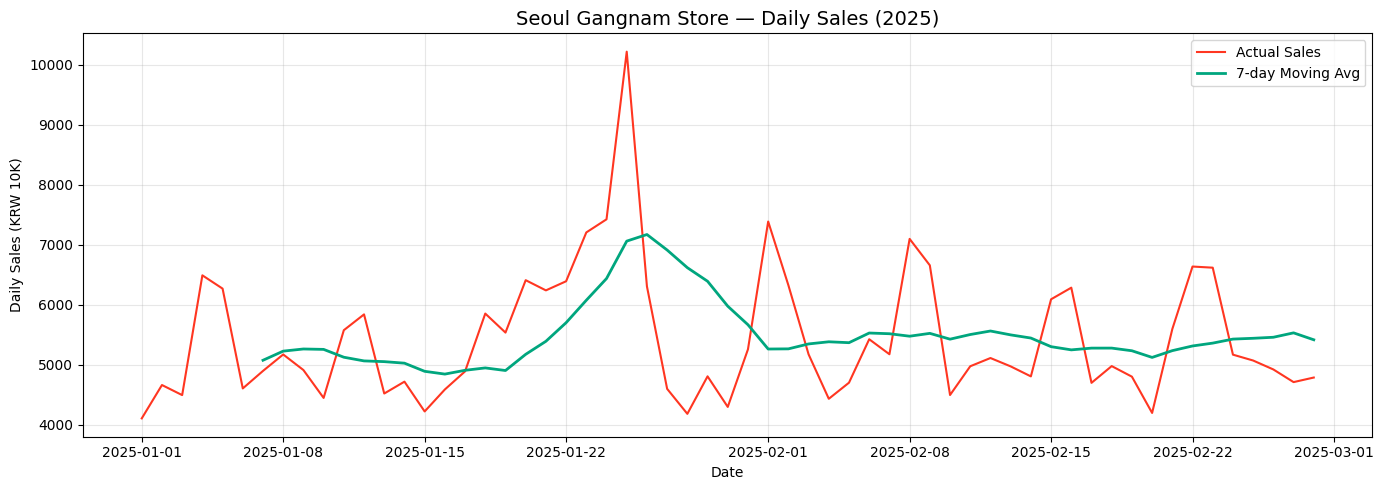

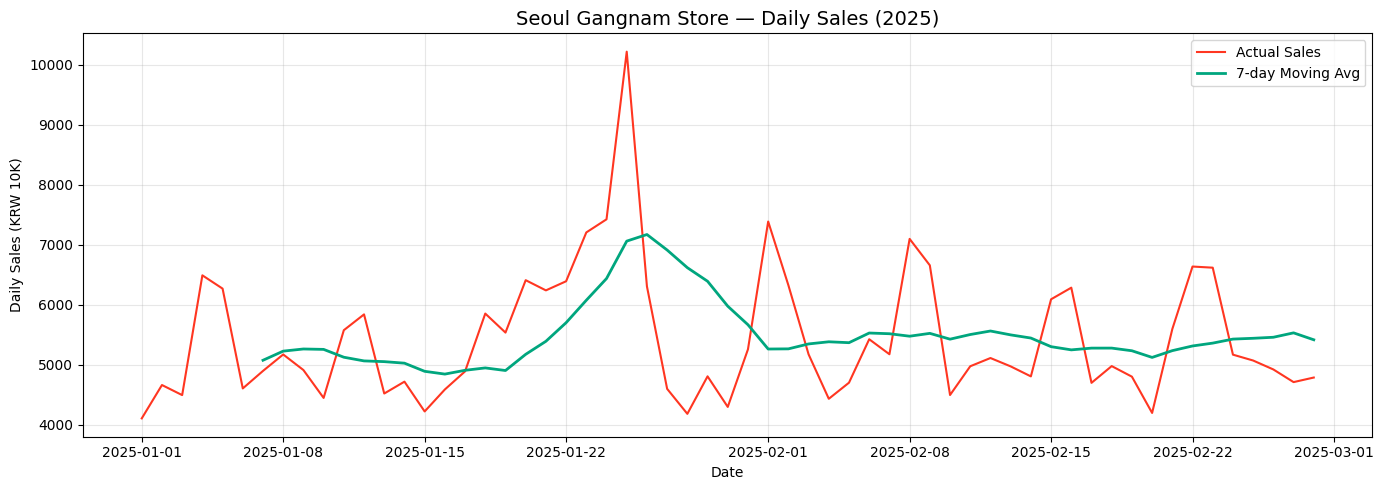

In [0]:
# 간단한 예측 시각화 (학습 데이터의 마지막 90일 + 예측 비교)
import matplotlib.pyplot as plt

# 강남점 최근 데이터
recent_gangnam = (
    spark.table(f"{CATALOG}.{SCHEMA}.retail_sales_forecast")
    .filter(F.col("store_id") == "Seoul_Gangnam")
    .filter(F.col("date") >= "2025-01-01")
    .orderBy("date")
    .toPandas()
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(recent_gangnam["date"], recent_gangnam["daily_sales"],
        color="#FF3621", linewidth=1.5, label="Actual Sales")

# 7일 이동평균 트렌드 추가
recent_gangnam["ma7"] = recent_gangnam["daily_sales"].rolling(7).mean()
ax.plot(recent_gangnam["date"], recent_gangnam["ma7"],
        color="#00A67E", linewidth=2, label="7-day Moving Avg")

ax.set_title("Seoul Gangnam Store — Daily Sales (2025)", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Daily Sales (KRW 10K)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
display(fig)

In [0]:
# 매장별 요약 통계
store_summary = (
    spark.table(f"{CATALOG}.{SCHEMA}.retail_sales_forecast")
    .groupBy("store_id")
    .agg(
        F.avg("daily_sales").alias("avg_daily_sales"),
        F.stddev("daily_sales").alias("stddev_sales"),
        F.min("daily_sales").alias("min_sales"),
        F.max("daily_sales").alias("max_sales"),
        F.sum("daily_sales").alias("total_sales"),
    )
    .orderBy(F.desc("total_sales"))
)

display(store_summary)

store_id,avg_daily_sales,stddev_sales,min_sales,max_sales,total_sales
Seoul_Gangnam,6319.446556962024,1570.7955072488594,3155.67,14703.21,4992362.779999999
Seoul_Hongdae,4452.10034177215,1093.9449292872634,2227.02,10007.89,3517159.269999999
Busan_Haeundae,3545.732860759494,863.2737322605552,1451.95,8103.48,2801128.9600000004


## Part 5: 비즈니스 인사이트 도출

예측 모델을 학습했으니, 실무에서 어떻게 활용할 수 있을까요?

### 인사이트 1: 월별 매출 패턴 → 재고 계획

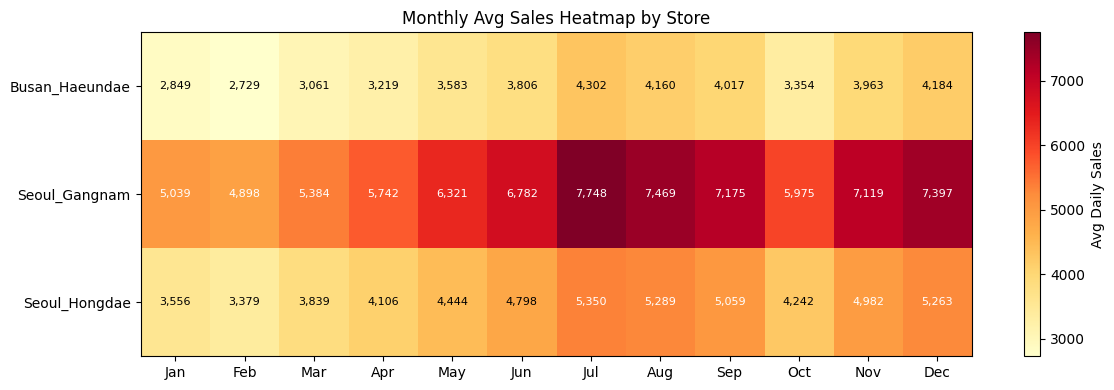

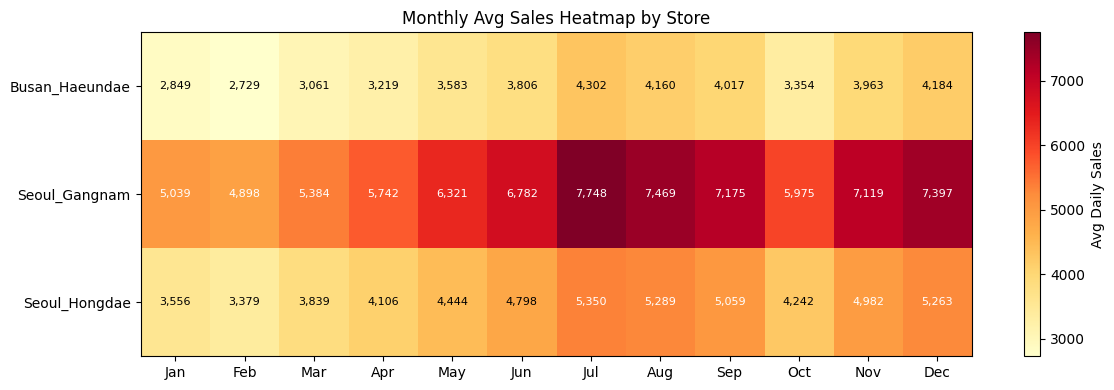

In [0]:
# 월별 매장별 평균 매출 히트맵 데이터
monthly_pattern = (
    spark.table(f"{CATALOG}.{SCHEMA}.retail_sales_forecast")
    .groupBy("store_id", "month")
    .agg(F.avg("daily_sales").alias("avg_sales"))
    .orderBy("store_id", "month")
    .toPandas()
)

pivot_df = monthly_pattern.pivot(index="store_id", columns="month", values="avg_sales")

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(pivot_df.values, cmap="YlOrRd", aspect="auto")
ax.set_xticks(range(12))
ax.set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
ax.set_yticks(range(len(stores)))
ax.set_yticklabels(pivot_df.index)
ax.set_title("Monthly Avg Sales Heatmap by Store")
plt.colorbar(im, ax=ax, label="Avg Daily Sales")

# 각 셀에 값 표시
for i in range(len(pivot_df.index)):
    for j in range(12):
        val = pivot_df.values[i, j]
        ax.text(j, i, f"{val:,.0f}", ha="center", va="center", fontsize=8,
                color="white" if val > pivot_df.values.mean() else "black")

plt.tight_layout()
display(fig)

### 인사이트 2: 요일별 매출 패턴 → 인력 배치

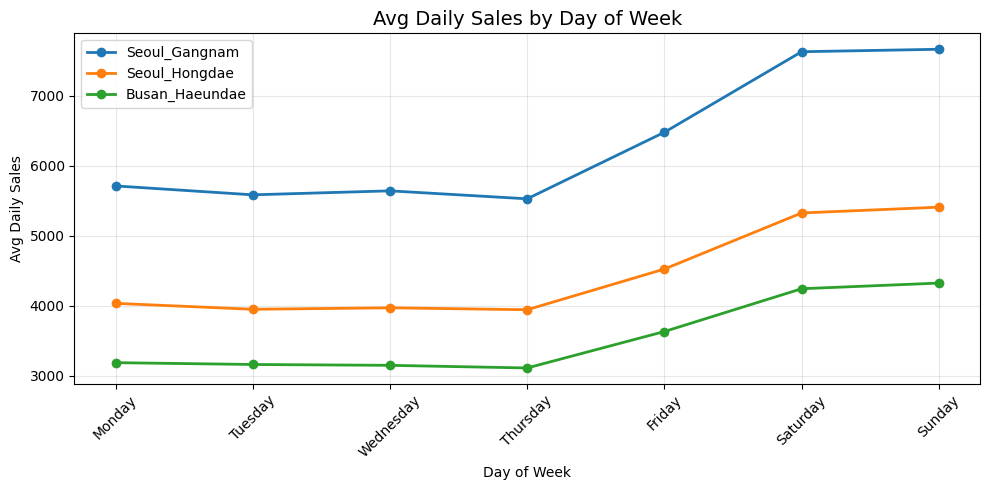

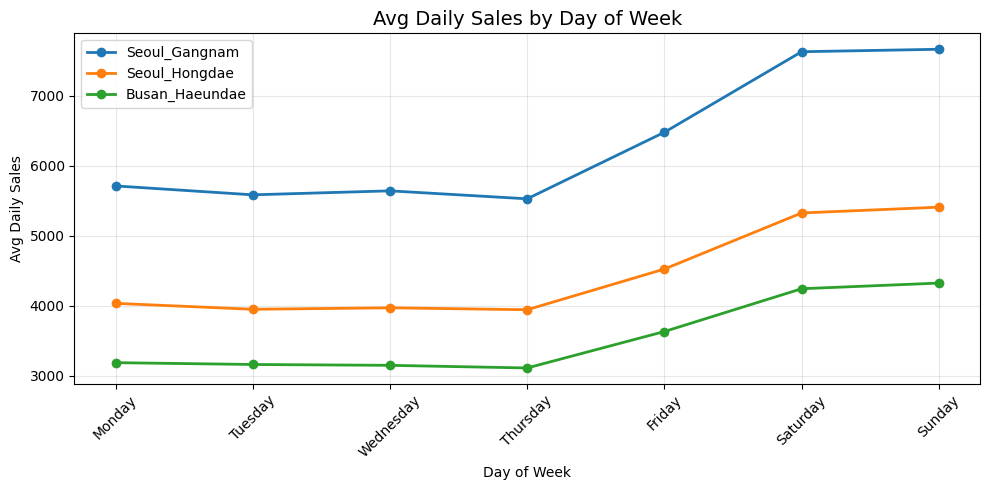

In [0]:
dow_pattern = (
    spark.table(f"{CATALOG}.{SCHEMA}.retail_sales_forecast")
    .groupBy("store_id", "day_of_week")
    .agg(F.avg("daily_sales").alias("avg_sales"))
    .toPandas()
)

dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_pattern["day_of_week"] = pd.Categorical(dow_pattern["day_of_week"], categories=dow_order, ordered=True)
dow_pattern = dow_pattern.sort_values("day_of_week")

fig, ax = plt.subplots(figsize=(10, 5))
for store in stores:
    store_data = dow_pattern[dow_pattern["store_id"] == store]
    ax.plot(store_data["day_of_week"], store_data["avg_sales"],
            marker="o", linewidth=2, label=store)

ax.set_title("Avg Daily Sales by Day of Week", fontsize=14)
ax.set_xlabel("Day of Week")
ax.set_ylabel("Avg Daily Sales")
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
display(fig)

### 인사이트 3: 성장률 분석 → 경영 보고

In [0]:
# 연도별 매장별 매출 비교
yearly = (
    spark.table(f"{CATALOG}.{SCHEMA}.retail_sales_forecast")
    .withColumn("year", F.year("date"))
    .groupBy("store_id", "year")
    .agg(F.sum("daily_sales").alias("annual_sales"))
    .orderBy("store_id", "year")
)

display(yearly)

store_id,year,annual_sales
Busan_Haeundae,2023,1253488.3599999999
Busan_Haeundae,2024,1368605.3400000005
Busan_Haeundae,2025,179035.26000000004
Seoul_Gangnam,2023,2233775.9899999998
Seoul_Gangnam,2024,2438001.6799999992
Seoul_Gangnam,2025,320585.11000000004
Seoul_Hongdae,2023,1576897.669999999
Seoul_Hongdae,2024,1719195.7099999997
Seoul_Hongdae,2025,221065.89000000007


In [0]:
# 전년 대비 성장률
yearly_pdf = yearly.toPandas()
for store in stores:
    store_data = yearly_pdf[yearly_pdf["store_id"] == store].sort_values("year")
    if len(store_data) >= 2:
        sales_2023 = store_data[store_data["year"] == 2023]["annual_sales"].values[0]
        sales_2024 = store_data[store_data["year"] == 2024]["annual_sales"].values[0]
        growth = (sales_2024 - sales_2023) / sales_2023 * 100
        print(f"{store}: 2023→2024 YoY Growth = {growth:.1f}%")

Seoul_Gangnam: 2023→2024 YoY Growth = 9.1%
Seoul_Hongdae: 2023→2024 YoY Growth = 9.0%
Busan_Haeundae: 2023→2024 YoY Growth = 9.2%


## Part 6: 실습 후 정리

In [0]:
# 임시 테이블 정리
spark.sql(f"DROP TABLE IF EXISTS {CATALOG}.{SCHEMA}.gangnam_sales_forecast")
spark.sql(f"DROP TABLE IF EXISTS {CATALOG}.{SCHEMA}.all_stores_sales_forecast")
# retail_sales_forecast는 다른 실습에서 재활용 가능하므로 유지
print("✅ 임시 테이블 정리 완료")
print(f"ℹ️ {CATALOG}.{SCHEMA}.retail_sales_forecast 테이블은 유지됩니다.")

✅ 임시 테이블 정리 완료
ℹ️ 3dt005_databricks.default.retail_sales_forecast 테이블은 유지됩니다.


## 🎯 핵심 정리

| 항목 | 내용 |
|------|------|
| **API** | `databricks.automl.forecast()` |
| **알고리즘** | Prophet, ARIMA (자동 선택) |
| **단일 시계열** | `time_col` + `target_col` |
| **다중 시계열** | `identity_col`로 그룹 지정 → 매장/제품별 개별 모델 |
| **주요 파라미터** | `frequency` (d/W/M), `horizon` (예측 기간) |
| **비용 제어** | `timeout_minutes`로 실행 시간 제한 |

### 실무 활용 포인트

- **재고 관리**: 월별 매출 패턴 → 계절별 발주 계획
- **인력 배치**: 요일별 매출 패턴 → 주말/평일 인력 최적화
- **경영 보고**: 성장률 분석 + 향후 매출 예측 → 투자/확장 의사결정
- **프로모션 효과**: 특별 이벤트 기간 매출 변화 → 마케팅 ROI 측정

### classify / regress / forecast 비교

| | classify | regress | forecast |
|--|---------|---------|----------|
| **문제** | 범주 예측 | 수치 예측 | 미래 수치 예측 |
| **예시** | 이탈 여부 | 집 가격 | 다음달 매출 |
| **알고리즘** | XGBoost, LightGBM, RF | XGBoost, LightGBM, RF | Prophet, ARIMA |
| **특수 파라미터** | - | - | frequency, horizon, identity_col |